# 03 - Regression
### Predicting a behavior-based cybersecurity risk score (0-100)

This notebook does **not** assign risk scores from labels (no
`BENIGN=0, DDoS=100` lookup). Instead it uses `src/risk_score.py`'s
`RiskScoreCalculator`, which derives a continuous score from behavioral
flow characteristics -- packet rate, byte rate, TCP flag anomalies, flow
duration extremity, and forward/backward traffic asymmetry -- normalized
by percentile rank and combined with documented weights. True labels are
only used afterward, as a sanity check that the score trends the way a
security analyst would expect -- never as an input to the formula.


## 1. Imports

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

sys.path.insert(0, os.path.join("..", "src"))
import preprocessing as prep
import risk_score as rs
import utils

utils.set_plot_style()
RANDOM_STATE = 42
PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models", "regression")
FIGURES_DIR = os.path.join("..", "reports", "figures")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


## 2. Load the cleaned dataset and take a working sample

Same cleaned file and same sampling approach as the classification
notebook, for the same hardware-feasibility reasons -- see
`02_Classification.ipynb` section 3 for the full explanation.

In [2]:
clean_path = os.path.join(PROCESSED_DIR, "cleaned_dataset.csv")
if not os.path.exists(clean_path):
    raise FileNotFoundError(
        "data/processed/cleaned_dataset.csv not found. Run 01_EDA.ipynb first."
    )

df = pd.read_csv(clean_path, low_memory=False)
label_col = "label" if "label" in df.columns else df.columns[-1]

WORKING_SAMPLE_SIZE = 150_000
working_df = prep.stratified_sample(df, label_col=label_col, max_total=WORKING_SAMPLE_SIZE, min_per_class=200)
print(f"Working sample: {working_df.shape[0]:,} rows")


Working sample: 73,901 rows


## 3. Split BEFORE scoring -- fit the risk score formula on training data only

This mirrors the no-leakage discipline used for the scaler elsewhere in
this project: the risk score's percentile-normalization boundaries are a
fitted parameter, exactly like a scaler's mean/std, so they are computed
from the training split only and then applied to the test split.

In [3]:
# split_data() normally returns (X_train, X_test, y_train, y_test). Here we
# pass the whole working_df as "X" (keeping the label column alongside the
# features a little longer, for the sanity check below) and discard the
# separately-returned y copies with "_".
train_df, test_df, _, _ = prep.split_data(
    working_df, working_df[label_col], test_size=0.2, stratify=True, random_state=RANDOM_STATE
)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")


Train: (59120, 79), Test: (14781, 79)


## 4. Generate the risk score target

In [4]:
risk_calc = rs.RiskScoreCalculator()
risk_calc.fit(train_df)

train_scored = risk_calc.score(train_df)
test_scored = risk_calc.score(test_df)

y_train_risk = train_scored["risk_score"].to_numpy()
y_test_risk = test_scored["risk_score"].to_numpy()

print(f"Risk score range (train): {y_train_risk.min():.1f} - {y_train_risk.max():.1f}")
print(f"Risk score range (test):  {y_test_risk.min():.1f} - {y_test_risk.max():.1f}")
train_scored["risk_category"].value_counts()


Risk score range (train): 37.8 - 99.1
Risk score range (test):  37.8 - 98.3


risk_category
Medium    35154
High      23966
Low           0
Name: count, dtype: int64

### Sanity check (not used to build the score, only to validate it)

If the formula is meaningful, BENIGN traffic should trend toward lower
scores and attack categories toward higher ones -- checked here *after*
scoring, never fed back into the formula itself.

Mean risk score by true label (validation only):
label
Web Attack ï¿½ XSS              49.459466
Web Attack ï¿½ Brute Force      50.625782
DoS Slowhttptest                52.928805
DoS slowloris                   53.157270
DoS GoldenEye                   53.293895
DoS Hulk                        54.051525
Web Attack ï¿½ Sql Injection    54.305000
SSH-Patator                     59.972655
Infiltration                    62.317143
DDoS                            62.389940
FTP-Patator                     63.737361
BENIGN                          69.186635
Bot                             70.387487
Heartbleed                      71.465000
PortScan                        81.174625
Name: risk_score, dtype: float64


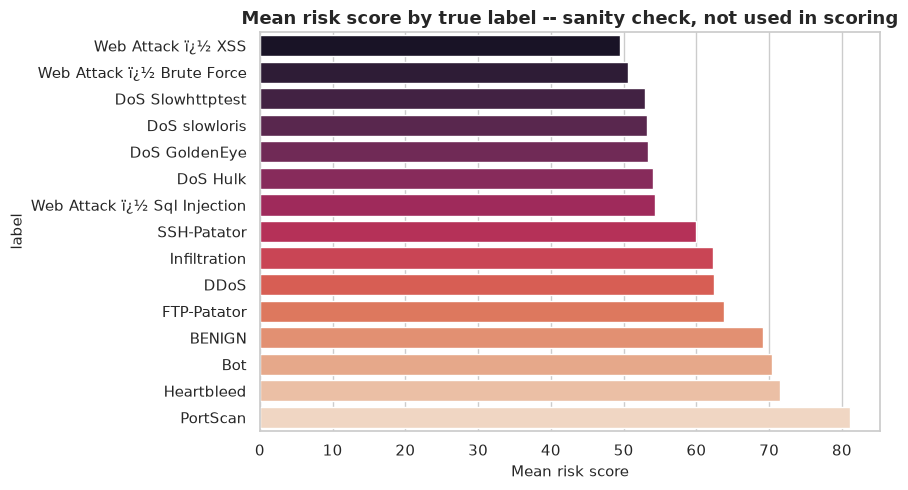

In [5]:
sanity = test_scored.copy()
sanity[label_col] = test_df[label_col].to_numpy()
mean_by_label = sanity.groupby(label_col)["risk_score"].mean().sort_values()
print("Mean risk score by true label (validation only):")
print(mean_by_label)

plt.figure(figsize=(9, 5))
sns.barplot(x=mean_by_label.values, y=mean_by_label.index, hue=mean_by_label.index, legend=False, palette="rocket")
plt.xlabel("Mean risk score")
plt.title("Mean risk score by true label -- sanity check, not used in scoring")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "risk_score_sanity_check.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. Feature/target preparation and scaling

In [6]:
X_train = train_df.drop(columns=[label_col])
X_test = test_df.drop(columns=[label_col])
feature_names = list(X_train.columns)

X_train_scaled, X_test_scaled, scaler = prep.scale_features(X_train, X_test)
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (59120, 78), Test: (14781, 78)


## 6. The 10 required algorithms

| # | Algorithm | Core idea |
|---|---|---|
| 1 | Linear Regression | Fits a single hyperplane minimizing squared error |
| 2 | Ridge | Linear regression with an L2 penalty -- shrinks coefficients, reduces overfitting |
| 3 | Lasso | Linear regression with an L1 penalty -- can shrink some coefficients to exactly zero |
| 4 | ElasticNet | Combines L1 and L2 penalties |
| 5 | Polynomial Regression | Linear regression on polynomial-expanded features -- captures curved/interaction effects |
| 6 | Decision Tree Regressor | Piecewise-constant predictions from learned if/else splits |
| 7 | Random Forest Regressor | Bagged ensemble of regression trees |
| 8 | Gradient Boosting Regressor | Sequential trees fit to residual errors |
| 9 | Support Vector Regression | Fits within an epsilon-margin tube, penalizing points outside it |
| 10 | KNN Regression | Predicts the average target value of the nearest training points |

**On Polynomial Regression specifically:** expanding all ~78 raw features
to degree 2 would generate thousands of interaction terms -- too slow and
prone to overfitting for a laptop-scale demo. Instead we expand just the
5 behavioral indicators the risk score itself is built from
(`risk_calc.get_indicators(...)`), where pairwise interactions like
"packet rate x flag anomaly" are both cheap to compute and conceptually
meaningful.

In [7]:
poly_train = risk_calc.get_indicators(train_df).to_numpy()
poly_test = risk_calc.get_indicators(test_df).to_numpy()
print(f"Polynomial Regression input: {poly_train.shape[1]} raw indicators "
      f"-> {PolynomialFeatures(degree=2).fit(poly_train).n_output_features_} expanded terms")


Polynomial Regression input: 5 raw indicators -> 21 expanded terms


### Note on SVR's sub-sample

Same reasoning as SVM in the classification notebook: SVR's training cost
grows faster than linearly with row count. It is trained on a smaller
stratified sub-sample; every other regressor uses the full working
sample.

In [8]:
SVR_SAMPLE_SIZE = 20_000
svr_sample_df = prep.stratified_sample(working_df, label_col=label_col, max_total=SVR_SAMPLE_SIZE, min_per_class=50)
svr_train_df, svr_test_df, _, _ = prep.split_data(
    svr_sample_df, svr_sample_df[label_col], test_size=0.2, stratify=True, random_state=RANDOM_STATE
)

svr_risk_calc = rs.RiskScoreCalculator().fit(svr_train_df)
y_svr_train = svr_risk_calc.score(svr_train_df)["risk_score"].to_numpy()
y_svr_test = svr_risk_calc.score(svr_test_df)["risk_score"].to_numpy()

X_svr_train = svr_train_df.drop(columns=[label_col])
X_svr_test = svr_test_df.drop(columns=[label_col])
X_svr_train_scaled, X_svr_test_scaled, _ = prep.scale_features(X_svr_train, X_svr_test)
print(f"SVR sub-sample: {X_svr_train_scaled.shape[0]:,} train rows")


SVR sub-sample: 12,306 train rows


## 7. Train and evaluate every model

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.1, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=RANDOM_STATE),
    "KNN Regression": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
}

results = []
predictions = {}

for name, model in models.items():
    with utils.timer(name):
        model.fit(X_train_scaled, y_train_risk)
    result = utils.evaluate_regressor(model, X_test_scaled, y_test_risk, name)
    predictions[name] = result["_y_pred"]
    results.append(result)
    models[name] = model

# Polynomial Regression -- its own small feature set (see note above)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
with utils.timer("Polynomial Regression"):
    poly_model.fit(poly_train, y_train_risk)
poly_pred = poly_model.predict(poly_test)
poly_result = {
    "Model": "Polynomial Regression",
    "R2 Score": poly_model.score(poly_test, y_test_risk),
    "RMSE": float(np.sqrt(np.mean((y_test_risk - poly_pred) ** 2))),
    "MAE": float(np.mean(np.abs(y_test_risk - poly_pred))),
}
predictions["Polynomial Regression"] = poly_pred
results.append(poly_result)
models["Polynomial Regression"] = poly_model

# SVR -- its own smaller sub-sample (see note above)
svr_model = SVR(kernel="rbf")
with utils.timer("SVR"):
    svr_model.fit(X_svr_train_scaled, y_svr_train)
svr_result = utils.evaluate_regressor(svr_model, X_svr_test_scaled, y_svr_test, "SVR")
predictions["SVR"] = svr_result["_y_pred"]
results.append(svr_result)
models["SVR"] = svr_model

print("\nAll models trained.")


[Linear Regression] completed in 0.14 seconds
[Ridge] completed in 0.06 seconds
[Lasso] completed in 1.36 seconds
[ElasticNet] completed in 0.76 seconds
[Decision Tree] completed in 1.00 seconds
[Random Forest] completed in 9.52 seconds
[Gradient Boosting] completed in 27.35 seconds
[KNN Regression] completed in 0.01 seconds
[Polynomial Regression] completed in 0.02 seconds
[SVR] completed in 4.64 seconds

All models trained.


## 8. Comparison table and ranking

In [10]:
comparison_table = utils.build_comparison_table(results, primary_metric="R2 Score")
comparison_table


,Rank,R2 Score,RMSE,MAE
Model,,,,
Random Forest,1,0.999150,0.393179,0.139172
Decision Tree,2,0.998629,0.499351,0.167447
Gradient Boosting,3,0.993826,1.059507,0.684962
KNN Regression,4,0.986658,1.557475,0.473035
SVR,5,0.876003,4.508659,2.490204
Lasso,6,0.660442,7.857221,6.050487
ElasticNet,7,0.658111,7.884136,6.120130
Ridge,8,0.418007,10.286574,4.892909
Linear Regression,9,0.201472,12.049162,4.905922


In [11]:
comparison_table.to_csv(os.path.join(MODELS_DIR, "comparison_table.csv"))
print(f"Saved: {os.path.join(MODELS_DIR, 'comparison_table.csv')}")


Saved: ../models/regression/comparison_table.csv


## 9. 5-fold cross-validation for the top 2 models

A single train/test split can be lucky or unlucky -- cross-validation
gives a more reliable estimate of how the top performers generalize.

In [12]:
top_2_names = comparison_table.index[:2].tolist()
print(f"Top 2 models: {top_2_names}")

for name in top_2_names:
    model = models[name]
    if name in ("Polynomial Regression",):
        X_cv, y_cv = poly_train, y_train_risk
    elif name == "SVR":
        X_cv, y_cv = X_svr_train_scaled, y_svr_train
    else:
        X_cv, y_cv = X_train_scaled, y_train_risk

    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring="r2", n_jobs=-1)
    print(f"{name}: R2 = {scores.mean():.4f} +/- {scores.std():.4f}  (per-fold: {np.round(scores, 3)})")


Top 2 models: ['Random Forest', 'Decision Tree']
Random Forest: R2 = 0.9992 +/- 0.0001  (per-fold: [0.999 0.999 0.999 0.999 0.999])
Decision Tree: R2 = 0.9985 +/- 0.0001  (per-fold: [0.998 0.999 0.999 0.998 0.999])


## 10. Visualizations for the best model

Best model: Random Forest


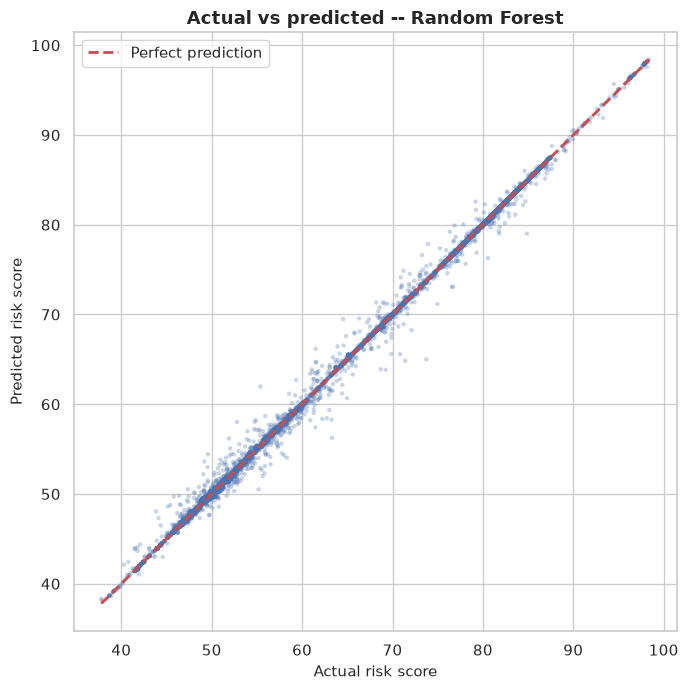

In [13]:
best_name = comparison_table.index[0]
best_model = models[best_name]
best_pred = predictions[best_name]
best_y_test = y_svr_test if best_name == "SVR" else y_test_risk

print(f"Best model: {best_name}")
utils.plot_actual_vs_predicted(best_y_test, best_pred, best_name,
                                save_path=os.path.join(FIGURES_DIR, "regression_actual_vs_predicted.png"))


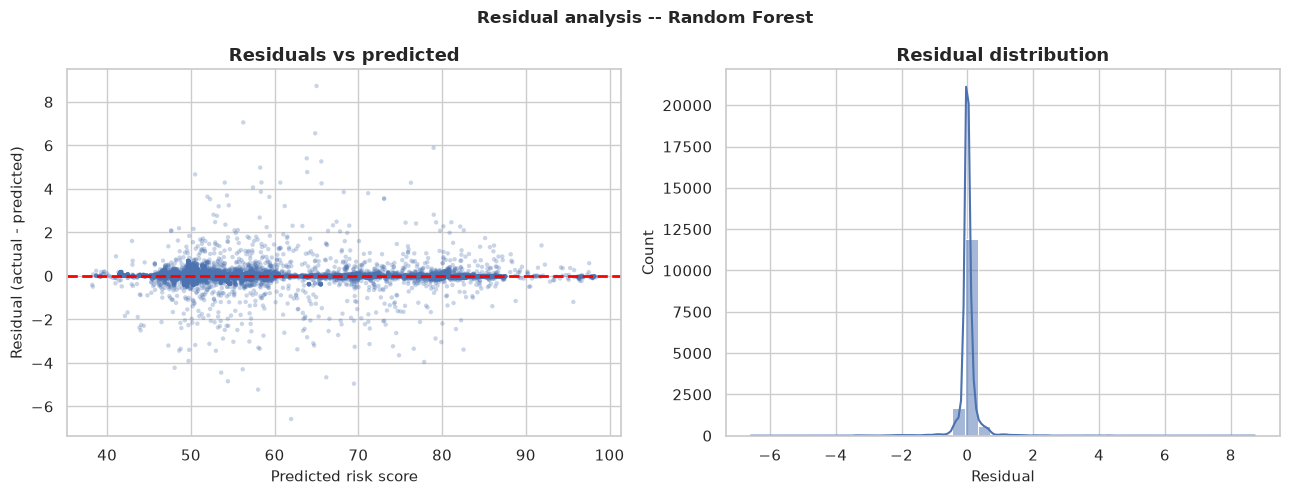

array([-0.01066167,  0.13265559, -0.01859382, ..., -0.06050633,
       -0.08978421, -0.10804466], shape=(14781,))

In [14]:
utils.plot_residuals(best_y_test, best_pred, best_name,
                      save_path=os.path.join(FIGURES_DIR, "regression_residuals.png"))


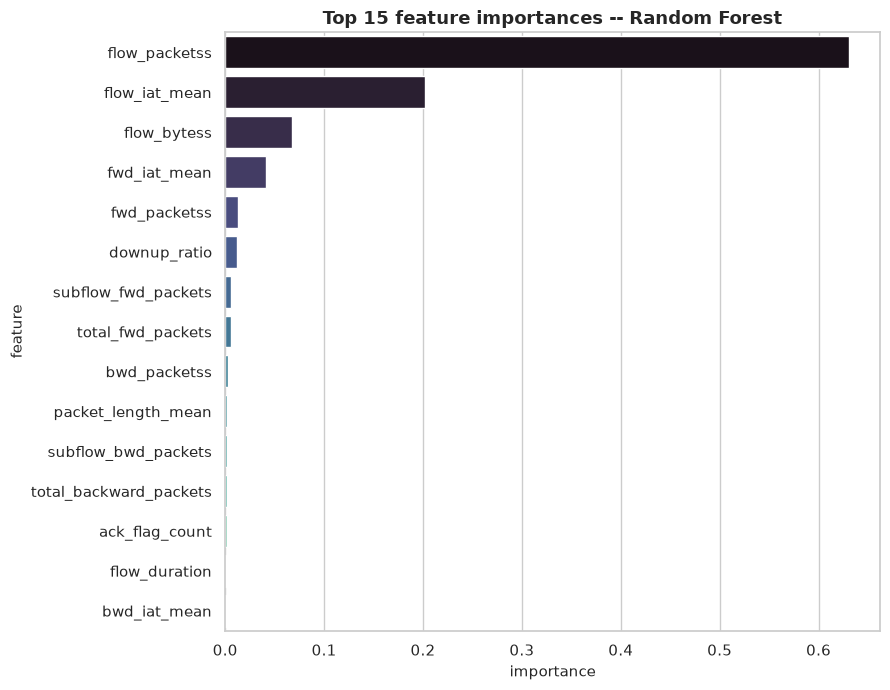

In [15]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature", legend=False, palette="mako")
    plt.title(f"Top 15 feature importances -- {best_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "regression_feature_importance.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"{best_name} has no feature_importances_ attribute -- this is expected for "
          "linear models, SVR, and KNN. The coefficients (for linear models) or the "
          "actual-vs-predicted plot above are the relevant diagnostics instead.")


## 11. Save the final model and supporting artifacts

Includes the fitted `RiskScoreCalculator` itself (not just the regression
model) -- the app needs it to derive the same risk-score target from any
newly uploaded traffic, using the exact percentile boundaries learned
here.

In [16]:
joblib.dump(best_model, os.path.join(MODELS_DIR, "best_model.joblib"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))
joblib.dump(risk_calc, os.path.join(MODELS_DIR, "risk_score_calculator.joblib"))

with open(os.path.join(MODELS_DIR, "feature_names.json"), "w") as f:
    json.dump(feature_names, f, indent=2)

with open(os.path.join(MODELS_DIR, "model_info.json"), "w") as f:
    json.dump({
        "best_model_name": best_name,
        "r2_score": float(comparison_table.loc[best_name, "R2 Score"]),
        "uses_custom_feature_set": best_name in ("Polynomial Regression",),
    }, f, indent=2)

print(f"Saved best model ({best_name}) and supporting artifacts to {MODELS_DIR}")


Saved best model (Random Forest) and supporting artifacts to ../models/regression


## 12. Possible mistakes to watch for

- **Fitting the risk score formula on the full dataset instead of train
  only.** This notebook fits `RiskScoreCalculator` on `train_df` only --
  if you modify this, keep that boundary, or the percentile references
  (and therefore every score) leak test-set information.
- **Reading too much into the sanity check.** A moderate BENIGN-vs-attack
  gap in mean risk score is reassuring; a *perfect* separation would
  actually be suspicious -- it would suggest the formula is indirectly
  reconstructing the label rather than measuring independent behavior.
- **`Polynomial Regression`'s smaller feature set** means its R2 is not
  directly comparable in the same way as the other 9 models, which all
  see the full feature set -- worth a sentence about this in your report
  if Polynomial Regression ranks unexpectedly high or low.
- **SVR's separate sub-sample** means its score is measured on different
  rows than the other 9 -- treat its ranking as approximate.
